<a href="https://colab.research.google.com/github/ArjunAmbekar-iitdh/lightweight-llm-evaluation/blob/main/ultralight_llm_bench_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ultra-Light LLM Benchmark — Colab Baseline

Comparing **Gemma 3 1B-IT**, **Qwen 3 0.6B**, and **Qwen 3 1.7B** on a Colab T4 using HuggingFace transformers. This notebook is the Colab-side baseline; it produces a `results.json` that the Jetson Xavier port will extend with the same schema, so the two runs can be joined and compared directly.

**Metrics collected per model:**
- Model load time + on-disk size
- Time-to-first-token (TTFT)
- Decode throughput (tokens/sec, batch=1, greedy)
- Peak GPU VRAM
- Perplexity on a WikiText-2 slice
- (Qwen 3 only, secondary) thinking-mode on vs off

**Fairness controls:** fixed seed, greedy decoding, fixed prompt set, 3 warmup runs discarded, `attn_implementation="sdpa"` across all models.

> **Before running:** Runtime → Change runtime type → **T4 GPU**. Gemma 3 is gated on HuggingFace — accept the license at <https://huggingface.co/google/gemma-3-1b-it> and add your token to Colab Secrets as `HF_TOKEN`.

## 1. Install dependencies

Pinned to versions known to work with Gemma 3 and Qwen 3.

In [1]:
!pip install -q -U "transformers>=4.51.0" "accelerate>=0.33" "datasets>=2.19" "huggingface_hub>=0.24" "pandas>=2.0" "matplotlib>=3.7"
print("Done.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.6/642.6 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 15.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
db-dtyp

## 2. Setup, seeds, and HF auth

In [2]:
import os, sys, gc, json, time, random, shutil, threading, platform
from pathlib import Path
from dataclasses import dataclass, asdict, field
from typing import Optional

import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, TextIteratorStreamer, set_seed

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

# Environment
print(f"Python : {sys.version.split()[0]}")
print(f"Torch  : {torch.__version__}")
print(f"CUDA   : {torch.version.cuda}  available={torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"Host   : {platform.machine()} / {platform.system()}")

assert torch.cuda.is_available(), "No GPU detected. Set Runtime → T4 GPU."
DEVICE = "cuda"
DTYPE = torch.float16  # T4 has no native bf16; use fp16

Python : 3.12.13
Torch  : 2.10.0+cu128
CUDA   : 12.8  available=True
GPU    : Tesla T4
VRAM   : 15.64 GB
Host   : x86_64 / Linux


In [3]:
# HuggingFace auth — needed for gated Gemma 3
from huggingface_hub import login

HF_TOKEN = None
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = os.environ.get("HF_TOKEN")

if HF_TOKEN:
    login(token=HF_TOKEN, add_to_git_credential=False)
    print("Logged in to HuggingFace.")
else:
    print("WARNING: no HF_TOKEN found. Gemma 3 will fail to download.")
    print("Add your token to Colab Secrets (key icon) as HF_TOKEN, then re-run this cell.")

Logged in to HuggingFace.


## 3. Experiment configuration

The prompt set mixes short/long inputs and different task types so per-prompt numbers aren't dominated by one workload. Edit freely — just keep the set identical between Colab and Jetson runs.

In [4]:
# ---- Models ----
MODELS = [
    {"id": "google/gemma-3-1b-it",   "short": "gemma3-1b",   "family": "gemma3"},
    {"id": "Qwen/Qwen3-0.6B",        "short": "qwen3-0.6b",  "family": "qwen3"},
    {"id": "Qwen/Qwen3-1.7B",        "short": "qwen3-1.7b",  "family": "qwen3"},
]

# ---- Prompts (kept small; fair comparison matters more than volume) ----
PROMPTS = [
    {"id": "short_qa",       "text": "What is the capital of Australia? Answer in one sentence."},
    {"id": "instruction",    "text": "List three tips for writing clear technical documentation."},
    {"id": "reasoning",      "text": "If a train leaves at 9:15 and arrives at 11:42, how long was the trip? Show your steps."},
    {"id": "summarization",  "text": "Summarize in two sentences: The Industrial Revolution began in Britain in the late 18th century and spread through Europe and North America. It shifted economies from agrarian to manufacturing-based, introduced steam power and mechanized textile production, and drove mass urbanization. Working conditions were often poor, prompting later labor reforms."},
    {"id": "code",           "text": "Write a Python function that returns the nth Fibonacci number iteratively."},
]

# ---- Sampling (greedy for determinism) ----
GEN_CONFIG = {
    "max_new_tokens": 256,
    "do_sample": False,
    "temperature": 1.0,
    "top_p": 1.0,
    "repetition_penalty": 1.0,
}

# ---- Warmup + measurement repeats ----
WARMUP_RUNS = 3
MEASURE_RUNS = 3

# ---- Output location ----
OUT_DIR = Path("/content/bench_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_PATH = OUT_DIR / "results.json"

# ---- Platform tag (so we can join Colab + Jetson results later) ----
PLATFORM_TAG = {
    "name": "colab-t4",
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
    "arch": platform.machine(),
    "torch": torch.__version__,
    "cuda": torch.version.cuda,
}
print(json.dumps(PLATFORM_TAG, indent=2))

{
  "name": "colab-t4",
  "gpu": "Tesla T4",
  "arch": "x86_64",
  "torch": "2.10.0+cu128",
  "cuda": "12.8"
}


## 4. Benchmarking harness

Key design decisions:
- **TTFT** measured with `TextIteratorStreamer` in a background thread — first token arrival minus generate start.
- **Decode tok/s** = (generated_tokens − 1) / (total_time − TTFT), so prefill doesn't contaminate it.
- **Peak VRAM** via `torch.cuda.max_memory_allocated()`, reset per prompt.
- **Load time** measured around `from_pretrained` after the weights are cached locally (first run includes download, subsequent runs don't — we record both).

In [5]:
def get_disk_size_gb(model_id: str) -> float:
    """Size of cached model files on disk, in GB."""
    from huggingface_hub import scan_cache_dir
    total = 0
    try:
        for repo in scan_cache_dir().repos:
            if repo.repo_id == model_id:
                total = repo.size_on_disk
                break
    except Exception as e:
        print(f"  disk scan failed: {e}")
    return total / 1e9

def load_model(model_id: str):
    """Load tokenizer + model, returning (tok, model, load_time_s, disk_gb)."""
    print(f"Loading {model_id} ...")
    t0 = time.perf_counter()
    tok = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype=DTYPE,
        device_map=DEVICE,
        attn_implementation="sdpa",
    )
    model.eval()
    torch.cuda.synchronize()
    load_time = time.perf_counter() - t0
    disk_gb = get_disk_size_gb(model_id)
    print(f"  loaded in {load_time:.2f}s, on-disk {disk_gb:.2f} GB")
    return tok, model, load_time, disk_gb

In [6]:
def build_inputs(tok, family: str, prompt: str, enable_thinking: bool = False):
    """Apply the right chat template per family."""
    messages = [{"role": "user", "content": prompt}]
    kwargs = {"tokenize": False, "add_generation_prompt": True}
    # Qwen 3 supports enable_thinking flag in its template
    if family == "qwen3":
        kwargs["enable_thinking"] = enable_thinking
    text = tok.apply_chat_template(messages, **kwargs)
    return tok(text, return_tensors="pt").to(DEVICE)

@torch.inference_mode()
def benchmark_one(tok, model, family: str, prompt: str, enable_thinking: bool = False):
    """Single timed generation. Returns dict of metrics + output text."""
    inputs = build_inputs(tok, family, prompt, enable_thinking)
    prompt_tokens = inputs.input_ids.shape[1]

    streamer = TextIteratorStreamer(tok, skip_prompt=True, skip_special_tokens=True)
    gen_kwargs = dict(
        **inputs,
        streamer=streamer,
        pad_token_id=tok.pad_token_id or tok.eos_token_id,
        **GEN_CONFIG,
    )

    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

    t_start = time.perf_counter()
    thread = threading.Thread(target=model.generate, kwargs=gen_kwargs)
    thread.start()

    t_first = None
    out_text = ""
    n_tokens = 0
    for piece in streamer:
        if t_first is None:
            t_first = time.perf_counter()
        out_text += piece
        n_tokens += 1  # approximate: streamer yields detokenized chunks
    thread.join()
    t_end = time.perf_counter()
    torch.cuda.synchronize()

    # Re-count tokens accurately from the generated text
    n_out_tokens = len(tok(out_text, add_special_tokens=False).input_ids)

    ttft = (t_first - t_start) if t_first else float("nan")
    total = t_end - t_start
    decode_time = max(total - ttft, 1e-9)
    decode_tps = (n_out_tokens - 1) / decode_time if n_out_tokens > 1 else 0.0

    peak_vram_gb = torch.cuda.max_memory_allocated() / 1e9

    return {
        "prompt_tokens": int(prompt_tokens),
        "output_tokens": int(n_out_tokens),
        "ttft_s": float(ttft),
        "total_s": float(total),
        "decode_tps": float(decode_tps),
        "peak_vram_gb": float(peak_vram_gb),
        "output_preview": out_text[:240],
    }

In [7]:
@torch.inference_mode()
def compute_perplexity(tok, model, max_length: int = 1024, stride: int = 512):
    """Perplexity on a slice of WikiText-2 test set. Sliding window, negative log-likelihood."""
    from datasets import load_dataset
    ds = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
    text = "\n\n".join(t for t in ds["text"] if t.strip())
    # Cap input length to keep this fast; ~50k chars ≈ plenty for a stable estimate on small models
    text = text[:50000]
    enc = tok(text, return_tensors="pt")
    input_ids = enc.input_ids.to(DEVICE)
    seq_len = input_ids.size(1)

    nlls, total_tokens = [], 0
    prev_end = 0
    for begin in range(0, seq_len, stride):
        end = min(begin + max_length, seq_len)
        trg_len = end - prev_end
        ids = input_ids[:, begin:end]
        targets = ids.clone()
        targets[:, :-trg_len] = -100
        out = model(ids, labels=targets)
        # out.loss is mean over non-ignored tokens → multiply back
        nlls.append(out.loss.float() * trg_len)
        total_tokens += trg_len
        prev_end = end
        if end == seq_len:
            break
    ppl = torch.exp(torch.stack(nlls).sum() / total_tokens).item()
    return ppl

def free_model(model):
    """Aggressively free VRAM between models."""
    del model
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

## 5. Run the benchmark

~10–15 min on a T4 including downloads. Writes incrementally to `results.json` so a disconnect doesn't lose everything.

In [8]:
def summarize_runs(runs):
    """Median across MEASURE_RUNS per prompt → per-model aggregate."""
    import statistics as st
    keys = ["ttft_s", "total_s", "decode_tps", "peak_vram_gb", "output_tokens"]
    return {k: st.median(r[k] for r in runs) for k in keys}

all_results = {"platform": PLATFORM_TAG, "gen_config": GEN_CONFIG, "models": {}}

for m in MODELS:
    print(f"\n{'='*60}\n  {m['short']}  ({m['id']})\n{'='*60}")
    try:
        tok, model, load_time, disk_gb = load_model(m["id"])
    except Exception as e:
        print(f"  FAILED to load: {e}")
        all_results["models"][m["short"]] = {"error": str(e)}
        continue

    model_block = {
        "id": m["id"],
        "family": m["family"],
        "load_time_s": load_time,
        "disk_gb": disk_gb,
        "prompts": {},
        "perplexity": None,
    }

    # Determine which thinking modes to sweep
    thinking_modes = [False] if m["family"] != "qwen3" else [False, True]

    for thinking in thinking_modes:
        tag = "think_off" if not thinking else "think_on"
        print(f"\n  -- mode: {tag} --")

        for prompt in PROMPTS:
            # Warmup
            for _ in range(WARMUP_RUNS):
                benchmark_one(tok, model, m["family"], prompt["text"], enable_thinking=thinking)
            # Measure
            runs = [
                benchmark_one(tok, model, m["family"], prompt["text"], enable_thinking=thinking)
                for _ in range(MEASURE_RUNS)
            ]
            agg = summarize_runs(runs)
            key = f"{prompt['id']}__{tag}"
            model_block["prompts"][key] = {
                "prompt_id": prompt["id"],
                "thinking": thinking,
                "aggregate": agg,
                "runs": runs,
                "output_preview": runs[-1]["output_preview"],
            }
            print(f"    {prompt['id']:15s}  TTFT {agg['ttft_s']*1000:6.0f} ms   decode {agg['decode_tps']:5.1f} tok/s   VRAM {agg['peak_vram_gb']:.2f} GB")

    # Perplexity (non-thinking context only — just the LM objective)
    print("\n  -- perplexity (WikiText-2 slice) --")
    try:
        ppl = compute_perplexity(tok, model)
        model_block["perplexity"] = ppl
        print(f"    ppl = {ppl:.3f}")
    except Exception as e:
        print(f"    perplexity failed: {e}")
        model_block["perplexity_error"] = str(e)

    all_results["models"][m["short"]] = model_block

    # Incremental save
    with open(RESULTS_PATH, "w") as f:
        json.dump(all_results, f, indent=2)
    print(f"\n  saved → {RESULTS_PATH}")

    free_model(model)
    del tok

print("\nAll models done.")


  gemma3-1b  (google/gemma-3-1b-it)
Loading google/gemma-3-1b-it ...


config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

  loaded in 151.91s, on-disk 4.08 GB

  -- mode: think_off --
    short_qa         TTFT     61 ms   decode  15.5 tok/s   VRAM 5.46 GB
    instruction      TTFT     61 ms   decode  16.9 tok/s   VRAM 5.48 GB
    reasoning        TTFT     60 ms   decode  17.5 tok/s   VRAM 5.50 GB
    summarization    TTFT     62 ms   decode  18.3 tok/s   VRAM 5.48 GB
    code             TTFT     62 ms   decode  17.6 tok/s   VRAM 5.50 GB

  -- mode: think_on --
    short_qa         TTFT     61 ms   decode  17.7 tok/s   VRAM 5.48 GB
    instruction      TTFT     60 ms   decode  17.8 tok/s   VRAM 5.50 GB
    reasoning        TTFT     64 ms   decode  17.8 tok/s   VRAM 5.51 GB
    summarization    TTFT     60 ms   decode  17.7 tok/s   VRAM 5.51 GB
    code             TTFT     63 ms   decode  17.8 tok/s   VRAM 5.50 GB

  -- perplexity (WikiText-2 slice) --
    ppl = 17.020

  saved → /content/bench_results/results.json

All models done.


6. Results summary

In [9]:
import pandas as pd

rows = []
for short, mb in all_results["models"].items():
    if "error" in mb:
        continue
    for key, pb in mb["prompts"].items():
        agg = pb["aggregate"]
        rows.append({
            "model": short,
            "prompt": pb["prompt_id"],
            "thinking": pb["thinking"],
            "ttft_ms": agg["ttft_s"] * 1000,
            "decode_tps": agg["decode_tps"],
            "peak_vram_gb": agg["peak_vram_gb"],
            "output_tokens": agg["output_tokens"],
        })

df = pd.DataFrame(rows)
df.to_csv(OUT_DIR / "results_long.csv", index=False)

# Per-model summary (thinking off only, for clean cross-model comparison)
print("\n=== Per-model summary (thinking mode OFF) ===")
summary = (
    df[df.thinking == False]
    .groupby("model")
    .agg(
        ttft_ms=("ttft_ms", "median"),
        decode_tps=("decode_tps", "median"),
        peak_vram_gb=("peak_vram_gb", "max"),
    )
    .round(2)
)

# Add load_time, disk, perplexity
extras = pd.DataFrame([
    {
        "model": short,
        "load_s": round(mb.get("load_time_s", float("nan")), 2),
        "disk_gb": round(mb.get("disk_gb", float("nan")), 2),
        "perplexity": round(mb["perplexity"], 2) if mb.get("perplexity") else None,
    }
    for short, mb in all_results["models"].items() if "error" not in mb
]).set_index("model")

summary = summary.join(extras)
print(summary)
summary.to_csv(OUT_DIR / "summary.csv")


=== Per-model summary (thinking mode OFF) ===
            ttft_ms  decode_tps  peak_vram_gb  load_s  disk_gb  perplexity
model                                                                     
gemma3-1b     82.22       14.30          2.02   24.14     2.03       26.57
qwen3-0.6b    61.01       17.56          3.24   23.21     1.52       21.23
qwen3-1.7b    61.04       17.55          5.50  151.91     4.08       17.02


In [10]:
# Qwen 3: thinking on vs off comparison (if applicable)
qwen_df = df[df.model.str.startswith("qwen3")]
if not qwen_df.empty and qwen_df.thinking.nunique() > 1:
    print("=== Qwen 3 — thinking mode ON vs OFF ===")
    qsummary = (
        qwen_df.groupby(["model", "thinking"])
        .agg(
            ttft_ms=("ttft_ms", "median"),
            decode_tps=("decode_tps", "median"),
            output_tokens=("output_tokens", "median"),
        )
        .round(2)
    )
    print(qsummary)

=== Qwen 3 — thinking mode ON vs OFF ===
                     ttft_ms  decode_tps  output_tokens
model      thinking                                    
qwen3-0.6b False       61.01       17.56          134.0
           True        60.13       17.72          256.0
qwen3-1.7b False       61.04       17.55          136.0
           True        60.57       17.77          256.0


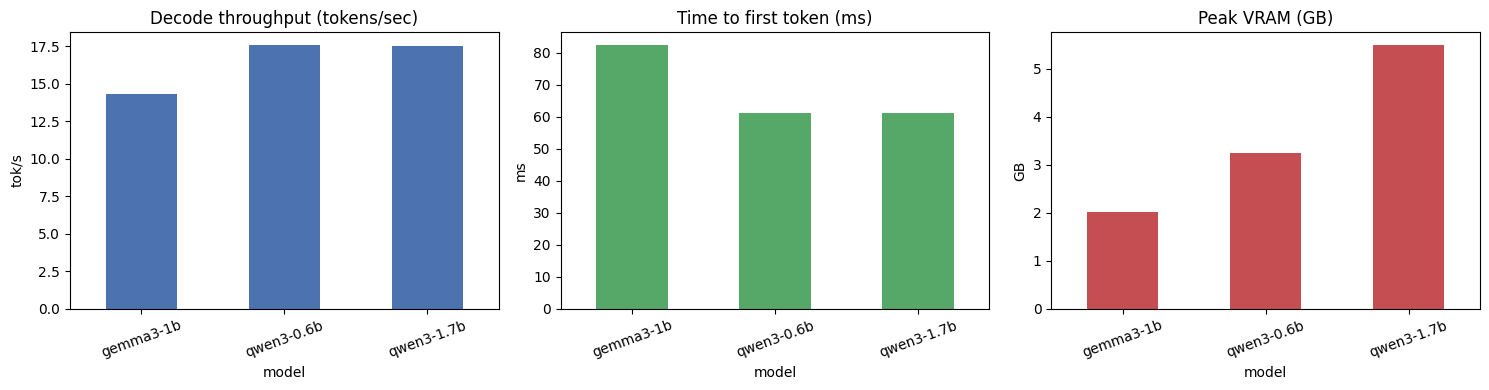

saved: /content/bench_results/summary.png


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_df = df[df.thinking == False].groupby("model").median(numeric_only=True)

plot_df["decode_tps"].plot.bar(ax=axes[0], color="#4c72b0")
axes[0].set_title("Decode throughput (tokens/sec)")
axes[0].set_ylabel("tok/s"); axes[0].tick_params(axis="x", rotation=20)

plot_df["ttft_ms"].plot.bar(ax=axes[1], color="#55a868")
axes[1].set_title("Time to first token (ms)")
axes[1].set_ylabel("ms"); axes[1].tick_params(axis="x", rotation=20)

plot_df["peak_vram_gb"].plot.bar(ax=axes[2], color="#c44e52")
axes[2].set_title("Peak VRAM (GB)")
axes[2].set_ylabel("GB"); axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(OUT_DIR / "summary.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"saved: {OUT_DIR / 'summary.png'}")

## 7. Next: porting to Jetson Xavier

The harness above is deliberately platform-agnostic — the only Colab-specific piece is the userdata HF token lookup. On Xavier:

1. **Flash a recent JetPack** (5.x or 6.x). Confirm with `sudo apt show nvidia-jetpack`.
2. **Use NVIDIA's PyTorch wheel** matched to your JetPack; pip-installed `torch` will not have CUDA. See <https://forums.developer.nvidia.com/t/pytorch-for-jetson/72048>.
3. **Lock the power mode** for reproducible numbers: `sudo nvpmodel -m 0 && sudo jetson_clocks`.
4. **Add power logging** — run `tegrastats --interval 500 --logfile tegra.log` alongside the benchmark; post-process to get avg watts and energy per token.
5. **Keep the prompt set, seed, `GEN_CONFIG`, and schema identical** so both `results.json` files can be joined on `(model, prompt, thinking)`.
6. **Expect aarch64-specific pain** with certain libs (bitsandbytes, flash-attn). You're already on `sdpa`, which is fine on Xavier.

Energy per token is the metric that turns this into a publishable comparison — Colab T4 will win on raw tok/s, but Xavier will likely win on tokens per joule, and that's the interesting edge-deployment story.